## PRÁCTICA INVERSIÓN PUBLICIDAD - REGRESIÓN

#### Estimar la contribución de cada medio de publicidad al impacto total de las SALES.
- Realizar una regresión multiple y explicar el fenomeno anterior a partir de los resultados obtenidos

1. Inspección inicial    → ¿qué tengo entre manos?
2. Análisis univariante  → ¿cómo se comporta cada variable por sí sola?
3. Análisis bivariante   → ¿cómo se relaciona cada X con la Y (Gasto)?
4. Matriz de correlación → vista panorámica de todas las relaciones
5. Modelo base (simple)  → empezar con la X que mejor pinta tiene
6. Modelo múltiple       → añadir todas las variables
7. Diagnóstico VIF       → ¿hay variables redundantes entre sí?
8. Análisis de residuos  → ¿el modelo cumple sus supuestos?
9. Decisión final        → qué variables se quedan y por qué

In [34]:
# ============================================
# LIBRERÍAS A USAR
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

In [35]:
## Cargamos los datos

data = pd.read_csv(r"Advertising.csv")

#### Inspección inicial

In [36]:
print("--- DIMENSIONES ---")
print("Filas:", data.shape[0], "| Columnas:", data.shape[1])

--- DIMENSIONES ---
Filas: 200 | Columnas: 4


In [37]:
print("\n--- TIPOS DE DATOS ---")
print(data.dtypes)


--- TIPOS DE DATOS ---
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


In [38]:
print("\n--- VALORES NULOS POR COLUMNA ---")
print(data.isnull().sum())


--- VALORES NULOS POR COLUMNA ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [39]:
print("\n--- PRIMERAS FILAS ---")
print(data.head())


--- PRIMERAS FILAS ---
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


In [40]:
print("\n--- RESUMEN ESTADISTICO ---")
print(data.describe().round(2))


--- RESUMEN ESTADISTICO ---
           TV   Radio  Newspaper   Sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   14.02
std     85.85   14.85      21.78    5.22
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   10.38
50%    149.75   22.90      25.75   12.90
75%    218.82   36.52      45.10   17.40
max    296.40   49.60     114.00   27.00


### Conclusiones
- 200 filas y 4 columnas
- TV: rango de 0.70 a 296.40. Media 147.04
- Radio: rango de 0 a 49.60. Media de 23.26
- Newspaper: rango 0.30 a 114. Media de 30.55
- *SALES: rango de 1.60 a 27. Media de 14.02

## Paso 2 — Análisis univariante

#### En este paso quremos mirar como se comportan cada variable por separado. 
##### Y queremos responder a las siguientes preguntas:
- ¿Los valores están concentrados en un rango o muy dispersos?
- ¿Hay valores extremos (outliers) que podrían distorsionar el modelo?
- ¿La distribución es simétrica (como una campana) o está sesgada hacia un lado?

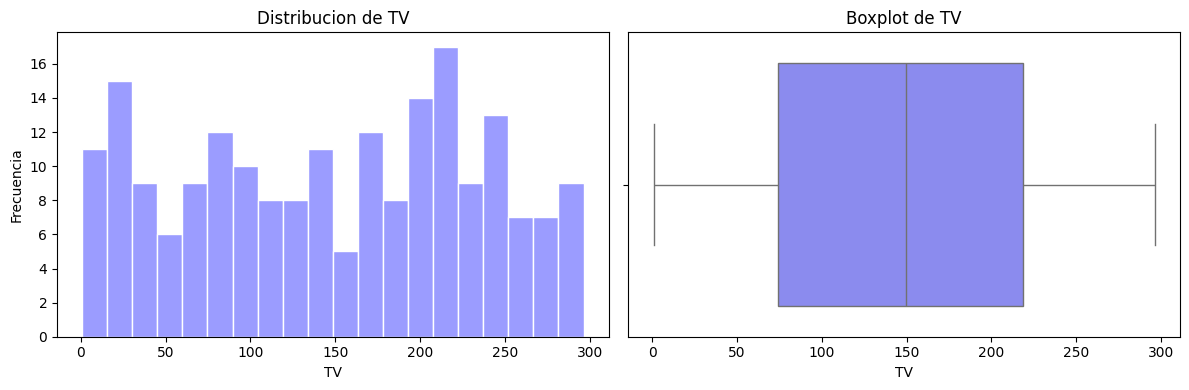

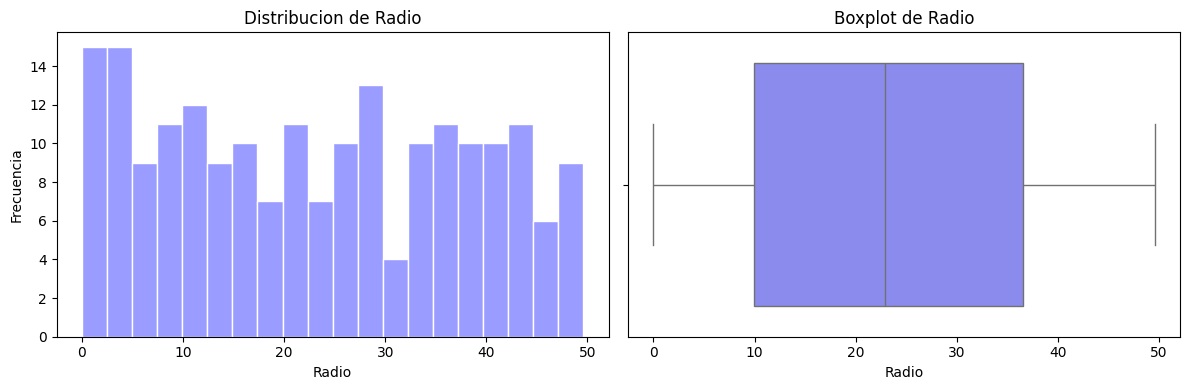

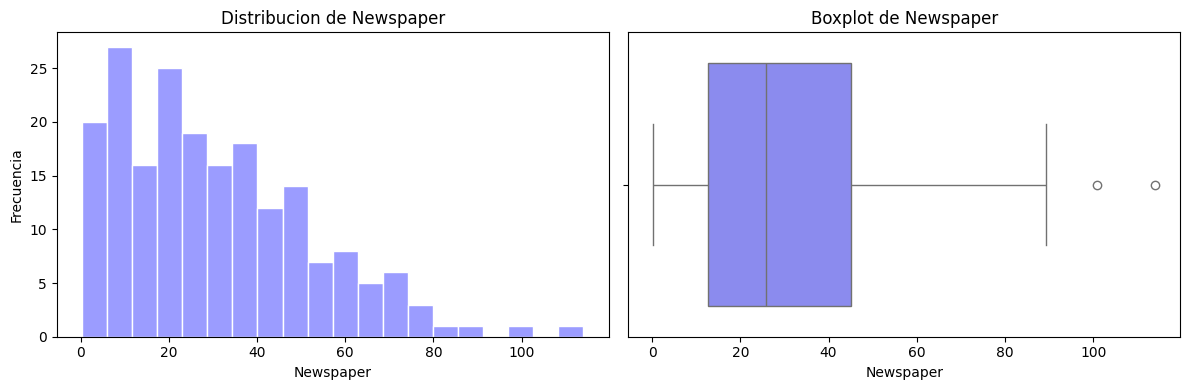

In [25]:
# Variables numericas continuas para analizar
variables_numericas = [
    "TV",
    "Radio",
    "Newspaper",
]

# Histogramas + boxplots (uno por variable)
for variable in variables_numericas:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histograma
    sns.histplot(data[variable], bins=20, ax=axes[0], color="#7a7bff", edgecolor="white")
    axes[0].set_title("Distribucion de " + variable)
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel("Frecuencia")

    # Boxplot
    sns.boxplot(x=data[variable], ax=axes[1], color="#7a7bff")
    axes[1].set_title("Boxplot de " + variable)
    axes[1].set_xlabel(variable)

    plt.tight_layout()
    plt.show()


## Paso 3 — Análisis bivariante

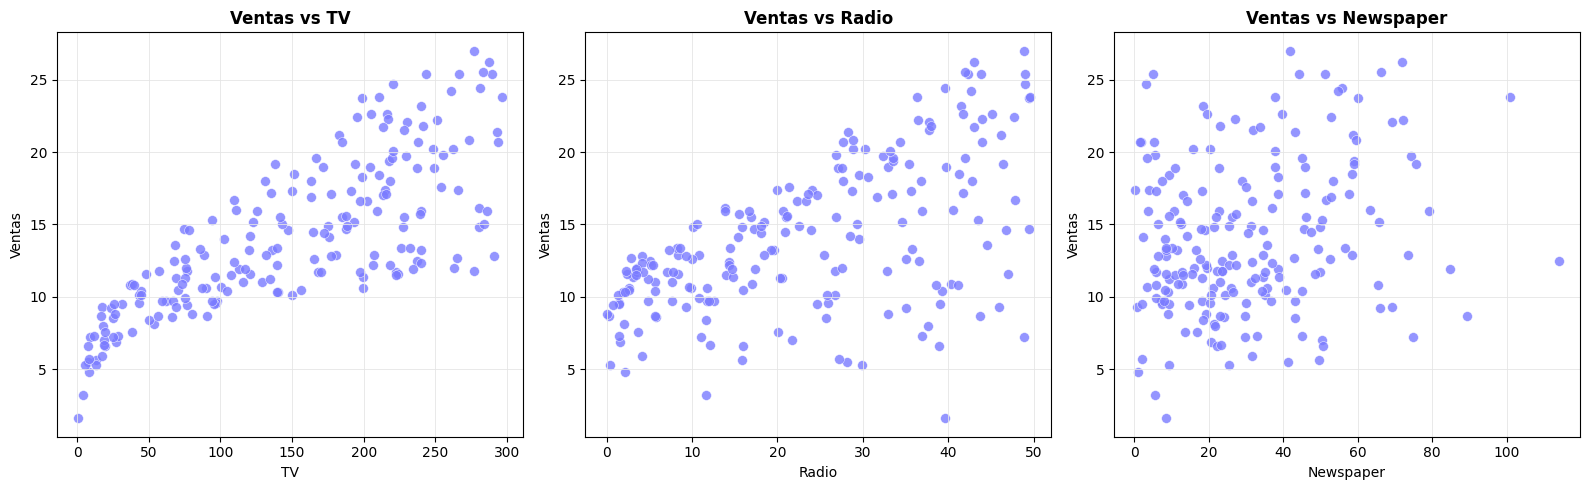

--- CORRELACION CON Ventas ---
TV           0.782
Radio        0.576
Newspaper    0.228
Sales        1.000
Name: Sales, dtype: float64


In [26]:
# Predictoras numericas vs Gasto (scatterplots)
predictoras_numericas = ["TV", "Radio", "Newspaper"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, variable in zip(axes, predictoras_numericas):
    ax.scatter(
        data[variable],
        data["Sales"],
        color="#7a7bff",
        edgecolor="white",
        linewidth=0.4,
        s=50,
        alpha=0.8,
    )
    ax.set_xlabel(variable)
    ax.set_ylabel("Ventas")
    ax.set_title("Ventas vs " + variable, fontweight="bold")
    ax.grid(color="#e5e5e5", linewidth=0.6)
plt.tight_layout()
plt.show()


# Correlacion numerica de cada predictora con la Y
print("--- CORRELACION CON Ventas ---")
columnas_para_correlar = predictoras_numericas + ["Sales"]
print(data[columnas_para_correlar].corr()["Sales"].round(3))

##### Conclusiones

- TV (0.782): nube compacta y ascendente (candidata fuerte)
- Radio(0.576): nube un poco menos compacta, pero ascendente.
- Newspaper: Nube más dispersa. Relación débil.

## Paso 4 — Matriz de correlación

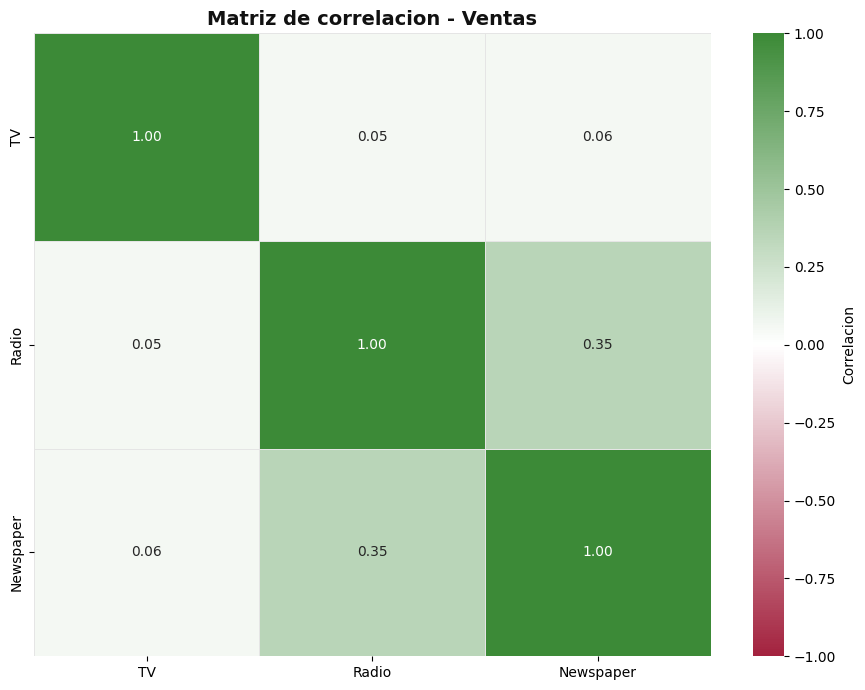

In [27]:
import matplotlib.colors as mcolors

# Variables a incluir (excluimos ID_Cliente: no es informacion, es solo etiqueta)
columnas_modelo = [
    "TV",
    "Radio",
    "Newspaper"
,
]

matriz_correlacion = data[columnas_modelo].corr()

# Colormap personalizado: rojo (negativo) - blanco (neutro) - verde (positivo)
cmap_marca = mcolors.LinearSegmentedColormap.from_list(
    "marca_personal", ["#a3223e", "#ffffff", "#3c8a37"]
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap=cmap_marca,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="#e5e5e5",
    cbar_kws={"label": "Correlacion"},
)
plt.title("Matriz de correlacion - Ventas", fontsize=14, fontweight="bold", color="#111111")
plt.tight_layout()
plt.show()

## Paso 5 — Modelo múltiple

##### Ahora vamos a introducir las variables que tenemos: TV, Radio y Newspaper

In [28]:
modelo_multiple_agencia = ols(
    "Sales ~ TV + Radio + Newspaper",
    data=data,
).fit()

print("--- RESUMEN DEL MODELO MULTIPLE ---")
print(modelo_multiple_agencia.summary().tables[1])
print("\nR2:", round(modelo_multiple_agencia.rsquared, 4))
print("R2-ajustado:", round(modelo_multiple_agencia.rsquared_adj, 4))

--- RESUMEN DEL MODELO MULTIPLE ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9389      0.312      9.422      0.000       2.324       3.554
TV             0.0458      0.001     32.809      0.000       0.043       0.049
Radio          0.1885      0.009     21.893      0.000       0.172       0.206
Newspaper     -0.0010      0.006     -0.177      0.860      -0.013       0.011

R2: 0.8972
R2-ajustado: 0.8956


### Observaciones
- TV y Radio tienen un p-valor inferior a 0.05
- Newspaper lo DESCARTAMOS por un p-valor superior a 0.05 --> 0.860 

#### Modelo múltiple pero ahora sin Newspaper

In [29]:
modelo_multiple_agencia_ii = ols(
    "Sales ~ TV + Radio",
    data=data,
).fit()

print("--- RESUMEN DEL MODELO MULTIPLE ---")
print(modelo_multiple_agencia_ii.summary().tables[1])
print("\nR2:", round(modelo_multiple_agencia_ii.rsquared, 4))
print("R2-ajustado:", round(modelo_multiple_agencia_ii.rsquared_adj, 4))

--- RESUMEN DEL MODELO MULTIPLE ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9211      0.294      9.919      0.000       2.340       3.502
TV             0.0458      0.001     32.909      0.000       0.043       0.048
Radio          0.1880      0.008     23.382      0.000       0.172       0.204

R2: 0.8972
R2-ajustado: 0.8962


## Paso 6 — Diagnóstico VIF

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

print("--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---")
matriz_x = modelo_multiple_agencia.model.exog
for i in range(1, matriz_x.shape[1]):
    vif = variance_inflation_factor(matriz_x, i)
    print("Variable", modelo_multiple_agencia.model.exog_names[i], ": VIF =", round(vif, 2))

# Determinante de la matriz de correlacion de las 5 predictoras
predictoras = ["TV", "Radio", "Newspaper"]
matriz_corre = data[predictoras].corr()
determinante = np.linalg.det(matriz_corre)
print("\nDeterminante:", round(determinante, 4))

if determinante < 0.01:
    print("Existe fuerte evidencia de multicolinealidad")
elif determinante < 0.1:
    print("Existe cierta multicolinealidad")
else:
    print("No se observan problemas importantes de multicolinealidad")

# Correlacion directa entre las dos variables sospechosas
print("\nCorrelacion Radio vs Newspaper:")
print(data[["Radio", "Newspaper"]].corr())

--- FACTOR DE INFLACION DE LA VARIANZA (VIF) ---
Variable TV : VIF = 1.0
Variable Radio : VIF = 1.14
Variable Newspaper : VIF = 1.15

Determinante: 0.8706
No se observan problemas importantes de multicolinealidad

Correlacion Radio vs Newspaper:
              Radio  Newspaper
Radio      1.000000   0.354104
Newspaper  0.354104   1.000000


- No se observan problemas de multicolinealidad. DETERMINANTE ESTA MUY LEJOS DEL 0

## Paso 7 — Análisis de residuos (modelo múltiple)

##### comprobar que los residuos (la diferencia entre lo real y lo predicho)
- ¿Están centrados en 0 y sin patrón? (linealidad bien capturada)
- ¿Su dispersión es constante en todo el rango? (homocedasticidad)
- ¿Se distribuyen aproximadamente como una campana? (normalidad)

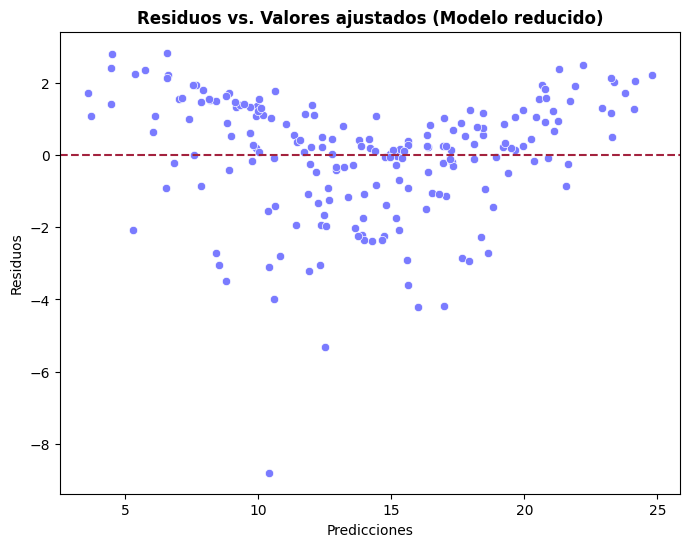

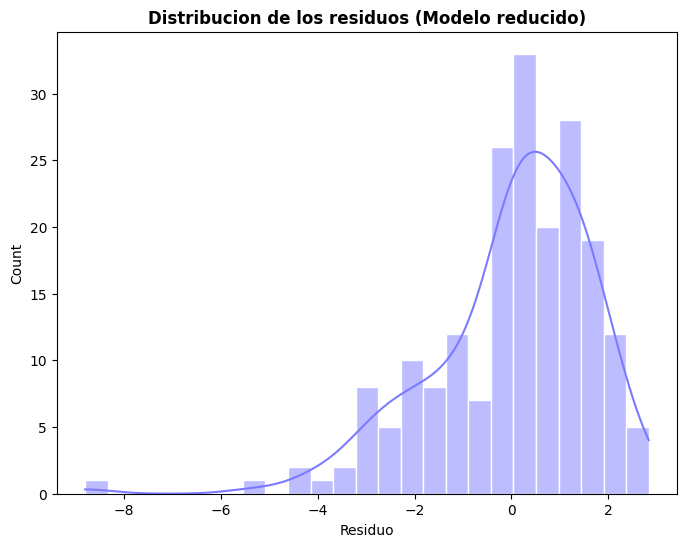

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           1.58e-96
Time:                        13:35:45   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9389      0.312      9.422      0.0

In [31]:
valores_ajustados_red = modelo_multiple_agencia_ii.fittedvalues
residuos_red = modelo_multiple_agencia_ii.resid

# Grafico 1: Residuos vs Valores ajustados
plt.figure(figsize=(8, 6))
sns.scatterplot(x=valores_ajustados_red, y=residuos_red, color="#7a7bff")
plt.axhline(y=0, color="#a3223e", linestyle="--", linewidth=1.5)
plt.title("Residuos vs. Valores ajustados (Modelo reducido)", fontweight="bold")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()

# Grafico 2: Distribucion de los residuos (¿forma de campana?)
plt.figure(figsize=(8, 6))
sns.histplot(residuos_red, bins=25, kde=True, color="#7a7bff", edgecolor="white")
plt.title("Distribucion de los residuos (Modelo reducido)", fontweight="bold")
plt.xlabel("Residuo")
plt.show()

# Diagnosticos formales (Omnibus, Jarque-Bera, Durbin-Watson)
print(modelo_multiple_agencia.summary())

## Modelo final

In [32]:
modelo_final = ols(
    "Sales ~ TV + Radio",
    data=data,
).fit()

print("--- RESUMEN DEL MODELO FINAL (sin Newspaper) ---")
print(modelo_final.summary().tables[1])
print("\nR2:", round(modelo_final.rsquared, 4))
print("R2-ajustado:", round(modelo_final.rsquared_adj, 4))

--- RESUMEN DEL MODELO FINAL (sin Newspaper) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9211      0.294      9.919      0.000       2.340       3.502
TV             0.0458      0.001     32.909      0.000       0.043       0.048
Radio          0.1880      0.008     23.382      0.000       0.172       0.204

R2: 0.8972
R2-ajustado: 0.8962


Este modelo explica el 89,72 % de las ventas

## Sales = 2.92 + 0.0458 × TV + 0.188 × Radio

- TV(0.0458) --> por cada 1000$ que invirtamos generamos 46 unidades de venta extra
- Radio(0.188) --> por cada 1000$ que invirtamos generamos 188 unidades de venta extra

Generamos mucho más con RADIO (media de 23$) que TV (nedia de 147$) con una inversión mucho menor. 

In [33]:
# Contribución media de cada canal a las ventas predichas
print("Contribución media por canal:")
print("TV:    ", round(modelo_final.params["TV"] * data["TV"].mean(), 2))
print("Radio: ", round(modelo_final.params["Radio"] * data["Radio"].mean(), 2))

Contribución media por canal:
TV:     6.73
Radio:  4.37


In [ ]:
### Explicación de como se calcula

# Coeficiente de TV  = 0.0458 x Media de TV (147.04) = 6.73
# % TV = 6.73 / 14.02(media de ventas) × 100 = 48.0 %

# Contribución Radio = 0.188 × 23.26 = 4.37
# % Radio = 4.37 / 14.02(media de ventas) × 100 = 31.2 %

## % contribución de X = (coeficiente_X × media_X) / media_Y × 100

: 